In [32]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go 
import plotly.io as pio   
pio.renderers.deffault = "notebook+png"
import plotly.colors as colors 
pio.templates.default = "plotly_white"

In [33]:
data = pd.read_csv("Sample - Superstore.csv", encoding='latin-1') 

In [34]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [35]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,4578.000000,4578.000000,4578.000000,4578.000000,4578.000000,4578.000000
mean,2289.500000,54879.289646,232.425959,3.802315,0.156686,26.212476
std,1321.699096,31767.037835,650.125232,2.245579,0.206231,211.017604
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-3839.990400
25%,1145.250000,22920.750000,16.768000,2.000000,0.000000,1.747800
50%,2289.500000,55122.000000,52.728000,3.000000,0.200000,8.713900
75%,3433.750000,90004.000000,213.394000,5.000000,0.200000,28.847950
max,4578.000000,99207.000000,22638.480000,14.000000,0.800000,5039.985600


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4578 entries, 0 to 4577
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         4578 non-null   int64  
 1   Order ID       4578 non-null   object 
 2   Order Date     4578 non-null   object 
 3   Ship Date      4578 non-null   object 
 4   Ship Mode      4578 non-null   object 
 5   Customer ID    4578 non-null   object 
 6   Customer Name  4578 non-null   object 
 7   Segment        4578 non-null   object 
 8   Country        4578 non-null   object 
 9   City           4578 non-null   object 
 10  State          4578 non-null   object 
 11  Postal Code    4578 non-null   int64  
 12  Region         4578 non-null   object 
 13  Product ID     4578 non-null   object 
 14  Category       4578 non-null   object 
 15  Sub-Category   4578 non-null   object 
 16  Product Name   4578 non-null   object 
 17  Sales          4578 non-null   float64
 18  Quantity

# Converting Date columns

In [37]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date']) 

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4578 entries, 0 to 4577
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         4578 non-null   int64         
 1   Order ID       4578 non-null   object        
 2   Order Date     4578 non-null   datetime64[ns]
 3   Ship Date      4578 non-null   datetime64[ns]
 4   Ship Mode      4578 non-null   object        
 5   Customer ID    4578 non-null   object        
 6   Customer Name  4578 non-null   object        
 7   Segment        4578 non-null   object        
 8   Country        4578 non-null   object        
 9   City           4578 non-null   object        
 10  State          4578 non-null   object        
 11  Postal Code    4578 non-null   int64         
 12  Region         4578 non-null   object        
 13  Product ID     4578 non-null   object        
 14  Category       4578 non-null   object        
 15  Sub-Category   4578 n

# Adding New Date-Based Columns

In [39]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [40]:
data['Order Month'] = data['Order Date'].dt.month 
data['Order Year'] = data['Order Date'].dt.year
data['Days taken to Deliver'] = data['Order Date'].dt.dayofweek

In [41]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Days taken to Deliver
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,6
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,6


# Monthly Sales Analysis

In [42]:
sales_by_month = data.groupby('Order Month')['Sales'].sum().reset_index()


In [43]:
sales_by_month

,Order Month,Sales
0,1,34593.5280
1,2,19465.8530
2,3,95255.6328
3,4,75971.5761
4,5,64599.1900
5,6,67943.2911
6,7,83603.6050
7,8,77328.6383
8,9,149513.4717
9,10,87893.0735


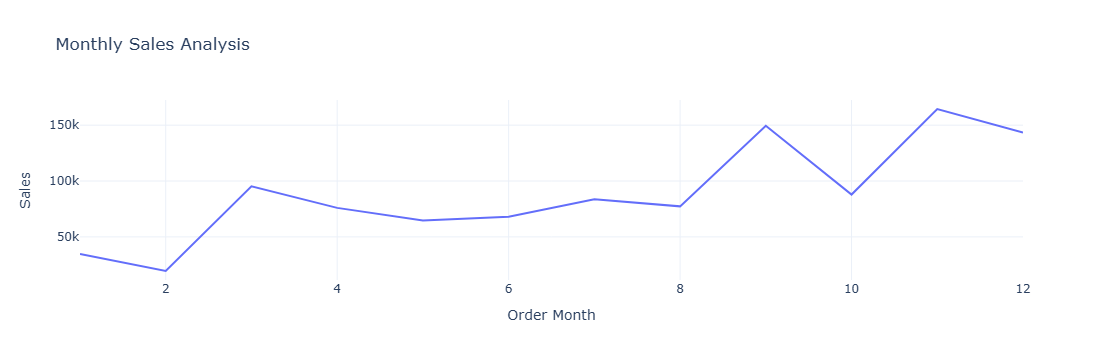

In [44]:
fig = px.line(sales_by_month, 
              x='Order Month', 
              y='Sales', 
              title='Monthly Sales Analysis')
fig.show()

# Sales Analysis by Category

In [45]:
sales_by_category = data.groupby('Category')['Sales'].sum().reset_index()

In [46]:
sales_by_category

,Category,Sales
0,Furniture,330574.6899
1,Office Supplies,326531.8950
2,Technology,406939.4570


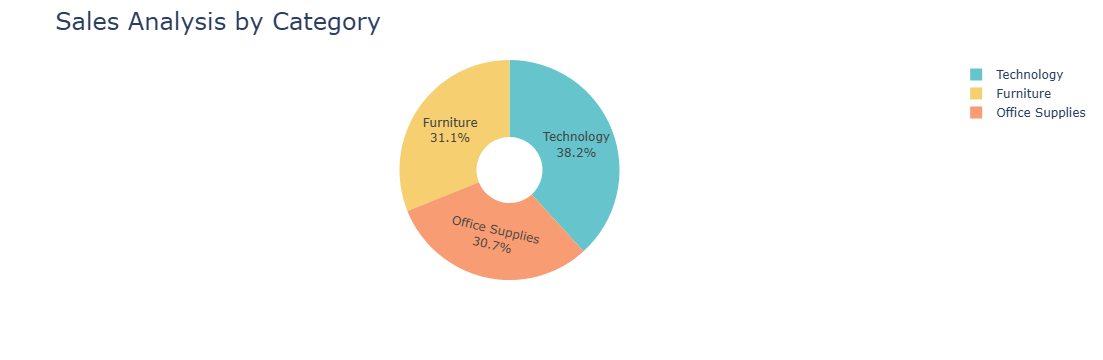

In [47]:
fig = px.pie(sales_by_category, 
             values='Sales', 
             names='Category', 
             hole=0.3, 
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(title_text='Sales Analysis by Category', title_font=dict(size=24))

fig.show()

# Sales Analysis by Sub-Category

In [48]:
sales_by_subcategory = data.groupby('Sub-Category')['Sales'].sum().reset_index()

In [49]:
sales_by_subcategory

,Sub-Category,Sales
0,Accessories,75510.1260
1,Appliances,47221.8870
2,Art,12755.4180
3,Binders,83589.6420
4,Bookcases,47900.7629
5,Chairs,140947.1460
6,Copiers,56129.2860
7,Envelopes,8129.9020
8,Fasteners,1563.9120
9,Furnishings,43557.4380


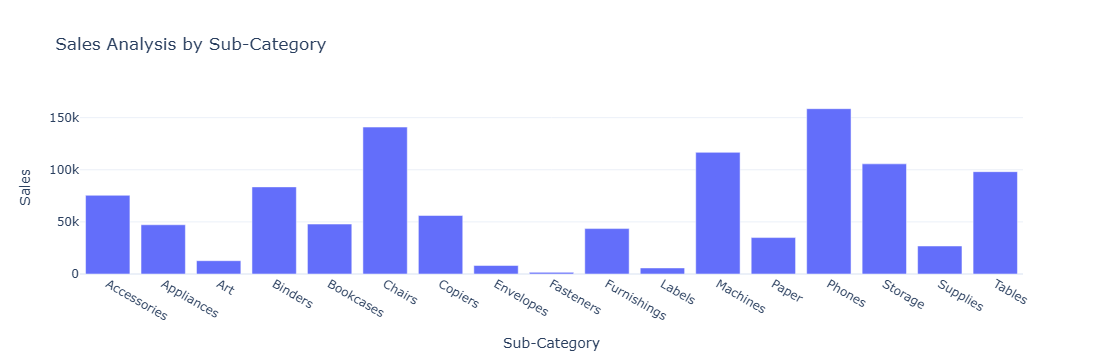

In [50]:
fig = px.bar(sales_by_subcategory, 
             x='Sub-Category', 
             y='Sales', 
             title='Sales Analysis by Sub-Category')
fig.show()

# Monthly Profit Analysis

In [51]:
profit_by_month = data.groupby('Order Month')['Profit'].sum().reset_index()

In [52]:
profit_by_month

,Order Month,Profit
0,1,3756.2376
1,2,2841.2308
2,3,12930.7485
3,4,3097.7883
4,5,11651.1519
5,6,6543.2068
6,7,9594.3808
7,8,11055.5037
8,9,11055.4646
9,10,12495.9116


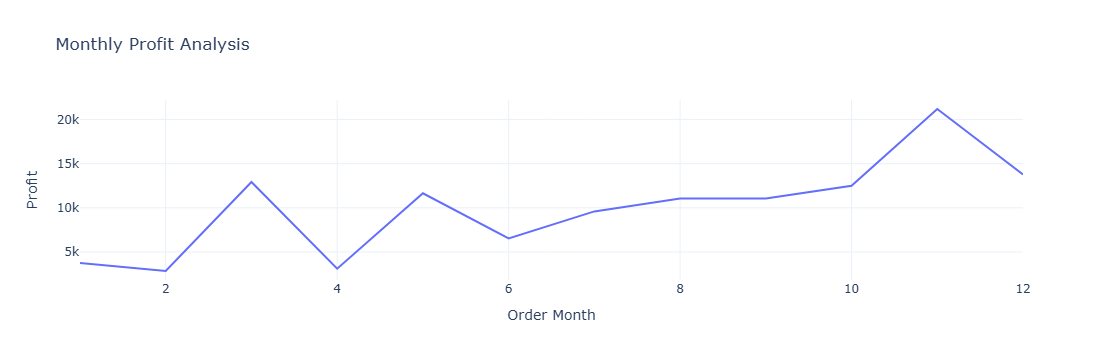

In [53]:
fig = px.line(profit_by_month, 
              x='Order Month', 
              y='Profit', 
              title='Monthly Profit Analysis')
fig.show()

# Profit Analysis by Category

In [54]:
profit_by_category = data.groupby('Category')['Profit'].sum().reset_index()

In [55]:
profit_by_category

,Category,Profit
0,Furniture,7910.0708
1,Office Supplies,54078.2733
2,Technology,58012.3697


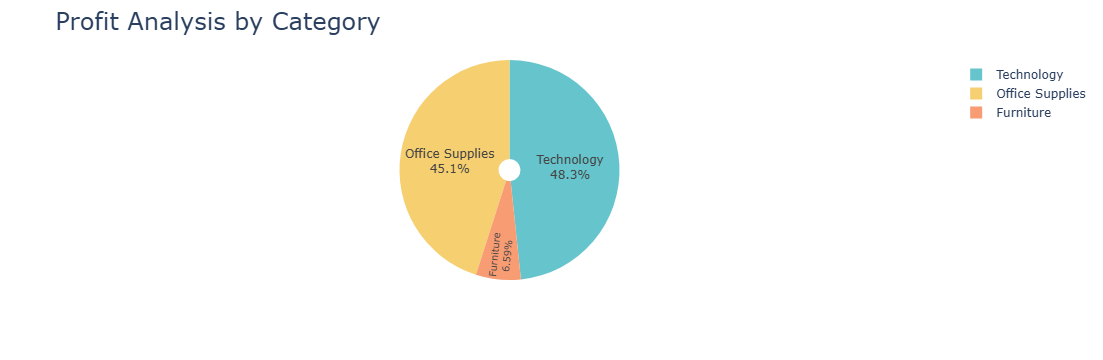

In [56]:
fig = px.pie(profit_by_category, 
             values='Profit', 
             names='Category', 
             hole=0.1, 
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(title_text='Profit Analysis by Category', title_font=dict(size=24))

fig.show()

# Profit Analysis by Sub-Category

In [57]:
profit_by_subcategory = data.groupby('Sub-Category')['Profit'].sum().reset_index()

In [58]:
profit_by_subcategory

,Sub-Category,Profit
0,Accessories,18638.2801
1,Appliances,8442.5277
2,Art,2931.9663
3,Binders,11954.6297
4,Bookcases,-1825.5294
5,Chairs,12394.8408
6,Copiers,20443.2607
7,Envelopes,3415.0987
8,Fasteners,535.2109
9,Furnishings,6311.7514


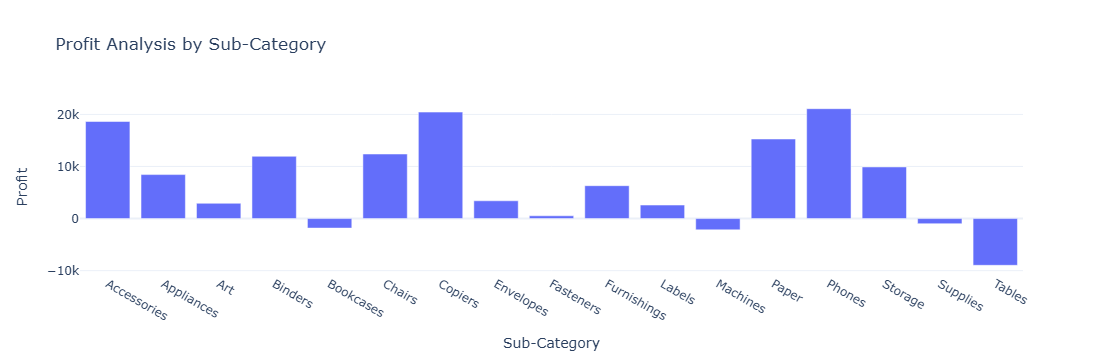

In [59]:
fig = px.bar(profit_by_subcategory, x='Sub-Category', 
             y='Profit', 
             title='Profit Analysis by Sub-Category')
fig.show()

# Sales and Profit Analysis by Customer Segment

In [60]:
sales_profit_by_segment = data.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()

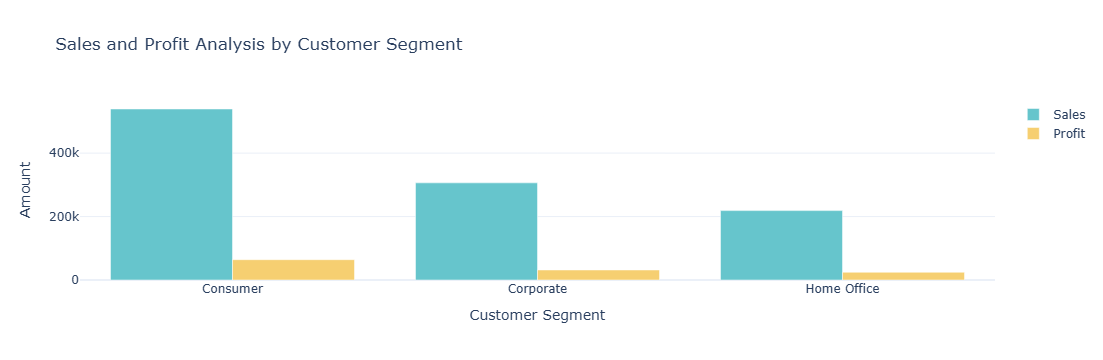

In [61]:
color_palette = colors.qualitative.Pastel

fig = go.Figure()
fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'], 
                     y=sales_profit_by_segment['Sales'], 
                     name='Sales',
                     marker_color=color_palette[0]))

fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'], 
                     y=sales_profit_by_segment['Profit'], 
                     name='Profit',
                     marker_color=color_palette[1]))

fig.update_layout(title='Sales and Profit Analysis by Customer Segment',
                  xaxis_title='Customer Segment', yaxis_title='Amount')

# Analysis of Sales-to-Profit Ratio

In [62]:
sales_profit_by_segment = data.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
sales_profit_by_segment['Sales_to_Profit_Ratio'] = sales_profit_by_segment['Sales'] / sales_profit_by_segment['Profit']
print(sales_profit_by_segment[['Segment', 'Sales_to_Profit_Ratio']])

       Segment  Sales_to_Profit_Ratio
0     Consumer               8.417732
1    Corporate               9.691612
2  Home Office               8.978531
